In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, academic visual style for the plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load the raw annotation data
file_path = './data/SBIC.v2.trn.csv'
df = pd.read_csv(file_path)

print(f"Total annotations in dataset: {len(df):,}")
display(df.head())

Total annotations in dataset: 112,900


,whoTarget,intentYN,sexYN,sexReason,offensiveYN,annotatorGender,annotatorMinority,sexPhrase,speakerMinorityYN,WorkerId,HITId,annotatorPolitics,annotatorRace,annotatorAge,post,targetMinority,targetCategory,targetStereotype,dataSource
0,0.0,0.66,0.0,NaN,1.0,woman,NaN,NaN,NaN,-8935932304856669427,363A7XIFV4G2799C5V96YERJA9AVAM,liberal,white,45.0,RT @_LexC__: I'm convinced that some of y'all ...,NaN,NaN,NaN,t/davidson
1,0.0,0.66,0.0,NaN,0.5,man,NaN,NaN,NaN,6347880360297734464,363A7XIFV4G2799C5V96YERJA9AVAM,mod-liberal,white,35.0,RT @_LexC__: I'm convinced that some of y'all ...,NaN,NaN,NaN,t/davidson
2,0.0,0.33,0.0,NaN,0.5,man,NaN,NaN,NaN,-7452610791699819066,363A7XIFV4G2799C5V96YERJA9AVAM,liberal,asian,23.0,RT @_LexC__: I'm convinced that some of y'all ...,NaN,NaN,NaN,t/davidson
3,1.0,1.00,0.0,NaN,1.0,man,NaN,NaN,0.0,-500114755446676507,3JTPR5MTZS6RLS3JBV4IOU0G2X35K5,liberal,white,25.0,RT @iBeZo: Stupid fucking nigger LeBron. You f...,black folks,race,all stupid,t/davidson
4,1.0,1.00,0.0,NaN,1.0,man,NaN,NaN,0.0,-500114755446676507,3JTPR5MTZS6RLS3JBV4IOU0G2X35K5,liberal,white,25.0,RT @iBeZo: Stupid fucking nigger LeBron. You f...,black folks,race,are not people but apes.,t/davidson


In [3]:
# Extract unique workers to see the true demographic breakdown
unique_workers = df.drop_duplicates(subset=['WorkerId'])

print(f"Total UNIQUE human annotators: {len(unique_workers):,}")


Total UNIQUE human annotators: 263


/tmp/ipykernel_14394/4032790682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=unique_workers, x='annotatorAge', ax=axes[0], palette='Blues_d', order=unique_workers['annotatorAge'].value_counts().index)
/tmp/ipykernel_14394/4032790682.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=unique_workers, x='annotatorRace', ax=axes[1], palette='Oranges_d', order=unique_workers['annotatorRace'].value_counts().index)
/tmp/ipykernel_14394/4032790682.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=unique_workers, x='a

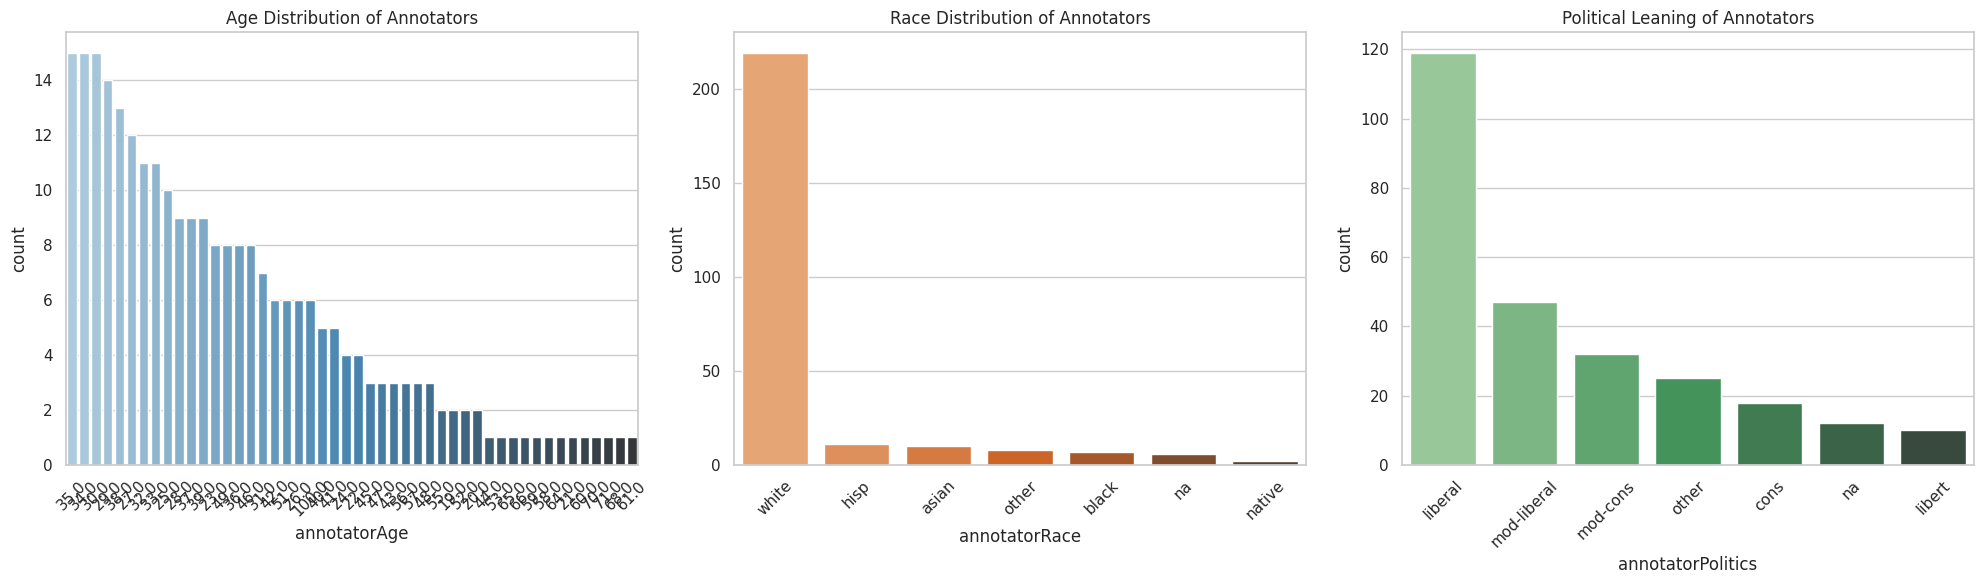

In [4]:
# Set up a 1x3 grid for our demographic plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Age Distribution
sns.countplot(data=unique_workers, x='annotatorAge', ax=axes[0], palette='Blues_d', order=unique_workers['annotatorAge'].value_counts().index)
axes[0].set_title('Age Distribution of Annotators')
axes[0].tick_params(axis='x', rotation=45)

# 2. Race Distribution
sns.countplot(data=unique_workers, x='annotatorRace', ax=axes[1], palette='Oranges_d', order=unique_workers['annotatorRace'].value_counts().index)
axes[1].set_title('Race Distribution of Annotators')
axes[1].tick_params(axis='x', rotation=45)

# 3. Political Leaning
sns.countplot(data=unique_workers, x='annotatorPolitics', ax=axes[2], palette='Greens_d', order=unique_workers['annotatorPolitics'].value_counts().index)
axes[2].set_title('Political Leaning of Annotators')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

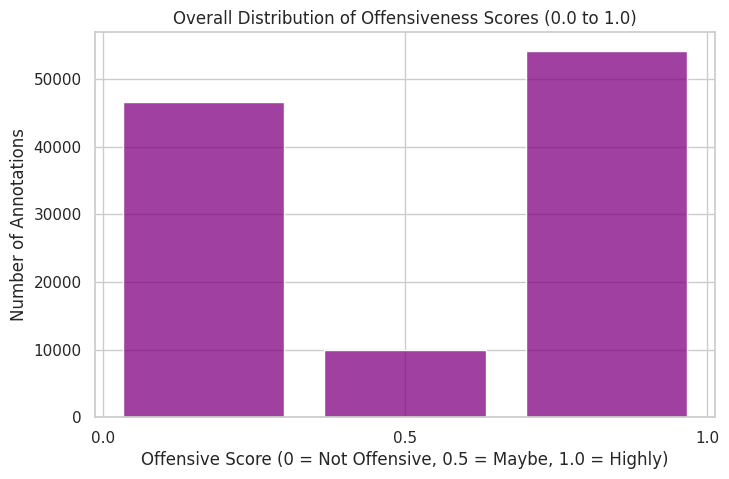

In [5]:
# Plot the distribution of the 'offensiveYN' scores
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='offensiveYN', bins=3, discrete=False, shrink=0.8, color='purple')

plt.title('Overall Distribution of Offensiveness Scores (0.0 to 1.0)')
plt.xlabel('Offensive Score (0 = Not Offensive, 0.5 = Maybe, 1.0 = Highly)')
plt.ylabel('Number of Annotations')
plt.xticks([0.0, 0.5, 1.0])
plt.show()

Annotation Sparsity Check:
count    35504.000000
mean         3.179923
std          1.172220
min          1.000000
25%          3.000000
50%          3.000000
75%          3.000000
max         16.000000
dtype: float64


/tmp/ipykernel_14394/3059103781.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=annotations_per_post.values, palette='muted')


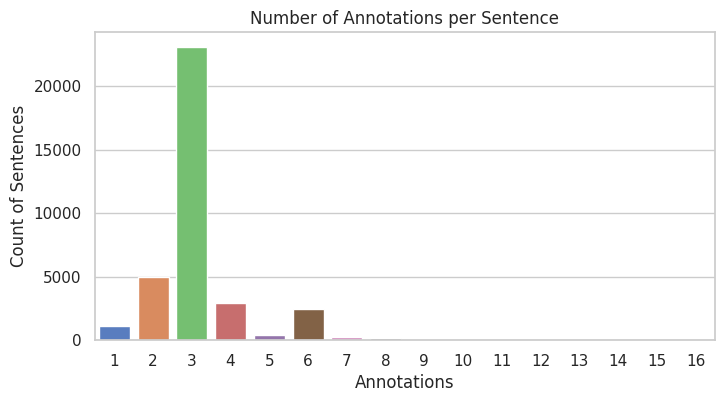

In [6]:
# Count how many annotations each unique post received
annotations_per_post = df.groupby('post').size()

print("Annotation Sparsity Check:")
print(annotations_per_post.describe())

plt.figure(figsize=(8, 4))
sns.countplot(x=annotations_per_post.values, palette='muted')
plt.title('Number of Annotations per Sentence')
plt.xlabel('Annotations')
plt.ylabel('Count of Sentences')
plt.show()

In [7]:
# Define Group A (e.g., White Conservatives)
group_A = df[(df['annotatorRace'].str.contains('white', na=False, case=False)) & 
             (df['annotatorPolitics'].str.contains('mod-cons', na=False, case=False))]

# Define Group B (e.g., Black Liberals)
group_B = df[(df['annotatorRace'].str.contains('black', na=False, case=False)) & 
             (df['annotatorPolitics'].str.contains('liberal', na=False, case=False))]

# Sample 500 rows from each to keep the overnight run manageable
# Using random_state ensures reproducibility!
sample_A = group_A.sample(n=500, random_state=42)
sample_B = group_B.sample(n=500, random_state=42)

print(f"Group A (White Conservatives) selected: {len(sample_A)} rows")
print(f"Group B (Black Liberals) selected: {len(sample_B)} rows")

# Save these to your data folder so you can SCP them to the HPC
sample_A.to_csv('./data/test_group_A.csv', index=False)
sample_B.to_csv('./data/test_group_B.csv', index=False)

print("Extraction complete! Ready for HPC.")

Group A (White Conservatives) selected: 500 rows
Group B (Black Liberals) selected: 500 rows
Extraction complete! Ready for HPC.


In [8]:
import numpy as np
import krippendorff
from scipy.spatial import distance

print("--- MACRO-DISTRIBUTIONS (For Jensen-Shannon Divergence) ---")

# Define a helper function to get a perfect [0.0, 0.5, 1.0] probability distribution array
def get_distribution(df, col='offensiveYN'):
    counts = df[col].value_counts(normalize=True)
    # Ensure all three categories exist in the array, even if 0
    dist = [counts.get(0.0, 0), counts.get(0.5, 0), counts.get(1.0, 0)]
    return np.array(dist)

dist_A = get_distribution(group_A)
dist_B = get_distribution(group_B)

print(f"Group A (White Conservatives) Distribution [0.0, 0.5, 1.0]: {dist_A}")
print(f"Group B (Black Liberals) Distribution [0.0, 0.5, 1.0]: {dist_B}")

# Example of JSD calculation: How far apart are these two human groups from each other?
human_jsd = distance.jensenshannon(dist_A, dist_B)
print(f"\nJSD between Human Group A and Human Group B: {human_jsd:.4f}")
print("(0.0 means identical, 1.0 means completely different)")

--- MACRO-DISTRIBUTIONS (For Jensen-Shannon Divergence) ---
Group A (White Conservatives) Distribution [0.0, 0.5, 1.0]: [0.29877194 0.12090992 0.58031814]
Group B (Black Liberals) Distribution [0.0, 0.5, 1.0]: [0.473551   0.05821311 0.46823589]

JSD between Human Group A and Human Group B: 0.1363
(0.0 means identical, 1.0 means completely different)


In [10]:
print("--- MICRO-VARIANCE (Krippendorff's Alpha) ---")

def calculate_alpha(df):
    # Pivot so Workers are rows and Posts are columns
    pivot_df = df.pivot_table(index='WorkerId', columns='post', values='offensiveYN', aggfunc='first')
    
    # Convert to a numpy array (krippendorff handles the np.nan values automatically)
    matrix = pivot_df.values
    
    # Calculate ordinal alpha (since 0.0 < 0.5 < 1.0)
    alpha = krippendorff.alpha(reliability_data=matrix, level_of_measurement='ordinal')
    return alpha

alpha_A = calculate_alpha(group_A)
alpha_B = calculate_alpha(group_B)

print(f"Human Group A (White Conservatives) Alpha: {alpha_A:.4f}")
print(f"Human Group B (Black Liberals) Alpha: {alpha_B:.4f}")
print("\nExpect these to be relatively low (e.g., 0.2 to 0.5). Humans disagree!")

--- MICRO-VARIANCE (Krippendorff's Alpha) ---
Human Group A (White Conservatives) Alpha: 0.7582
Human Group B (Black Liberals) Alpha: -0.1433

Expect these to be relatively low (e.g., 0.2 to 0.5). Humans disagree!


In [12]:
# Get a list of unique posts that Group A voted on
unique_posts_A = group_A[['post']].drop_duplicates().dropna()
# Get a list of unique posts that Group B voted on
unique_posts_B = group_B[['post']].drop_duplicates().dropna()

# Sample 500 unique sentences for the LLM to process
llm_test_A = unique_posts_A.sample(n=500, random_state=42)
llm_test_B = unique_posts_B.sample(n=500, random_state=42)

print(f"Generated {len(llm_test_A)} unique sentences for LLM Group A simulation.")
print(f"Generated {len(llm_test_B)} unique sentences for LLM Group B simulation.")

# Save to CSV (This will just be a single column of text!)
llm_test_A.to_csv('./data/llm_test_A.csv', index=False)
llm_test_B.to_csv('./data/llm_test_B.csv', index=False)
print("Saved! SCP these files to your HPC.")

Generated 500 unique sentences for LLM Group A simulation.
Generated 500 unique sentences for LLM Group B simulation.
Saved! SCP these files to your HPC.


In [13]:
print(f"Total Humans in Group A: {group_A['WorkerId'].nunique()}")
print(f"Total Humans in Group B: {group_B['WorkerId'].nunique()}")

Total Humans in Group A: 27
Total Humans in Group B: 4


In [17]:
# 1. Biggest Political Groups
print("--- Unique Workers by Politics ---")
print(df.groupby('annotatorPolitics')['WorkerId'].nunique().sort_values(ascending=False))

# 2. Biggest Gender Groups
print("\n--- Unique Workers by Gender ---")
print(df.groupby('annotatorGender')['WorkerId'].nunique().sort_values(ascending=False))

# 3. Biggest Intersections (Just in case!)
print("\n--- Top 5 Largest Intersectional Groups ---")
print(df.groupby(['annotatorRace', 'annotatorPolitics'])['WorkerId'].nunique().sort_values(ascending=False).head(5))

# 4. Biggest Race Groups
print("\n--- Unique Workers by Race ---")
print(df.groupby('annotatorRace')['WorkerId'].nunique().sort_values(ascending=False))

--- Unique Workers by Politics ---
annotatorPolitics
liberal        121
mod-liberal     52
mod-cons        32
other           26
cons            18
na              14
libert          11
Name: WorkerId, dtype: int64

--- Unique Workers by Gender ---
annotatorGender
woman        143
man          114
na             7
nonBinary      1
transman       1
Name: WorkerId, dtype: int64

--- Top 5 Largest Intersectional Groups ---
annotatorRace  annotatorPolitics
white          liberal              105
               mod-liberal           40
               mod-cons              27
               other                 20
               cons                  16
Name: WorkerId, dtype: int64

--- Unique Workers by Race ---
annotatorRace
white     219
hisp       11
asian      10
other       9
na          8
black       7
native      2
Name: WorkerId, dtype: int64
